In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    classification_report
)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.utils import resample

from xgboost import XGBClassifier

import shap

In [33]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(r"C:\Users\vivek\Desktop\KI_Project\Project 3\fetal_multimodal_dataset.csv")

print("Dataset Loaded Successfully")
print(df.shape)


# ============================================================
# 3. DEFINE FEATURES + TARGET
# ============================================================

TARGET_COLUMN = "target"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape) 

Dataset Loaded Successfully
(552, 28)

Feature Shape: (552, 27)
Target Shape: (552,)


In [34]:
# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)




Training Shape: (441, 27)
Testing Shape: (111, 27)


In [35]:
# ============================================================
# 6. CLASS IMBALANCE WEIGHT
# ============================================================

negative_count = y_train.value_counts()[0]
positive_count = y_train.value_counts()[1]

scale_pos_weight = negative_count / positive_count

print("\nScale Positive Weight:", scale_pos_weight)




Scale Positive Weight: 2.127659574468085


In [36]:
# ============================================================
# 7. BUILD XGBOOST PIPELINE
# ============================================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Identify categorical and numerical columns
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Create preprocessor for handling different data types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_columns),  # Keep numerical columns as-is
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)  # Encode categorical columns
    ])

# Build XGBoost pipeline with preprocessing
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist'
        # Removed 'use_label_encoder=False' to eliminate the warning
    ))
])

print("\nPipeline Created Successfully")

# ============================================================
# 8. QUICK TEST RUN
# ============================================================

# Fit the pipeline with preprocessing
pipeline.fit(X_train, y_train)

y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\nQuick Pipeline Test Successful")
print("First 5 Predictions:")
print(y_prob[:5])


Pipeline Created Successfully

Quick Pipeline Test Successful
First 5 Predictions:
[0.00436124 0.93329793 0.5150909  0.82140917 0.4757458 ]


In [37]:
# ============================================================
# 9. CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


In [38]:
# ============================================================
# 10. HYPERPARAMETER SEARCH SPACE
# ============================================================

param_dist = {

    'classifier__n_estimators': [100, 200, 300, 400],

    'classifier__max_depth': [3, 4, 5, 6],

    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],

    'classifier__subsample': [0.7, 0.8, 1.0],

    'classifier__colsample_bytree': [0.7, 0.8, 1.0],

    'classifier__gamma': [0, 0.1, 0.2, 0.3],

    'classifier__min_child_weight': [1, 3, 5],

    'classifier__reg_alpha': [0, 0.01, 0.1],

    'classifier__reg_lambda': [1, 1.5, 2]
}


In [39]:
# ============================================================
# 11. RANDOMIZED SEARCH
# ============================================================

search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=100,

    scoring='average_precision',

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

print("\nStarting Hyperparameter Search...\n")



Starting Hyperparameter Search...



In [40]:
# ============================================================
# 12. TRAIN MODEL
# ============================================================

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nHyperparameter Tuning Complete")


# ============================================================
# 13. BEST PARAMETERS
# ============================================================

print("\nBest Parameters:")
print(search.best_params_)

print("\nBest Cross-Validated PR-AUC:")
print(search.best_score_)



Fitting 10 folds for each of 100 candidates, totalling 1000 fits

Hyperparameter Tuning Complete

Best Parameters:
{'classifier__subsample': 1.0, 'classifier__reg_lambda': 1, 'classifier__reg_alpha': 0.01, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 5, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.8}

Best Cross-Validated PR-AUC:
0.5604884715762235


In [41]:
# ============================================================
# 14. G-MEAN THRESHOLD OPTIMIZATION
# ============================================================

# Predict probabilities on TRAIN set

y_train_prob = best_model.predict_proba(X_train)[:, 1]

# ROC Curve

fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)

# G-mean

gmeans = np.sqrt(tpr * (1 - fpr))

# Best threshold

ix = np.argmax(gmeans)

best_threshold = thresholds[ix]

print("\nBest Threshold:", best_threshold)
print("Best G-Mean:", gmeans[ix])



Best Threshold: 0.4981967
Best G-Mean: 0.926520219051941


In [42]:
# ============================================================
# 15. TEST SET EVALUATION
# ============================================================

y_test_prob = best_model.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_prob >= best_threshold).astype(int)



In [43]:
# 16. METRICS
# ============================================================

accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)

recall = recall_score(y_test, y_test_pred)

f1 = f1_score(y_test, y_test_pred)

roc_auc = roc_auc_score(y_test, y_test_prob)

pr_auc = average_precision_score(y_test, y_test_prob)

mcc = matthews_corrcoef(y_test, y_test_pred)

brier = brier_score_loss(y_test, y_test_prob)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

specificity = tn / (tn + fp)

In [44]:
# ============================================================
# 17. PRINT FINAL RESULTS
# ============================================================

print("\n========== FINAL MODEL PERFORMANCE ==========")

print(f"Accuracy      : {accuracy:.3f}")

print(f"Precision     : {precision:.3f}")

print(f"Recall        : {recall:.3f}")

print(f"Specificity   : {specificity:.3f}")

print(f"F1-score      : {f1:.3f}")

print(f"MCC           : {mcc:.3f}")

print(f"ROC-AUC       : {roc_auc:.3f}")

print(f"PR-AUC        : {pr_auc:.3f}")

print(f"Brier Score   : {brier:.3f}")


========== FINAL MODEL PERFORMANCE ==========
Accuracy      : 0.649
Precision     : 0.467
Recall        : 0.583
Specificity   : 0.680
F1-score      : 0.519
MCC           : 0.251
ROC-AUC       : 0.650
PR-AUC        : 0.506
Brier Score   : 0.225


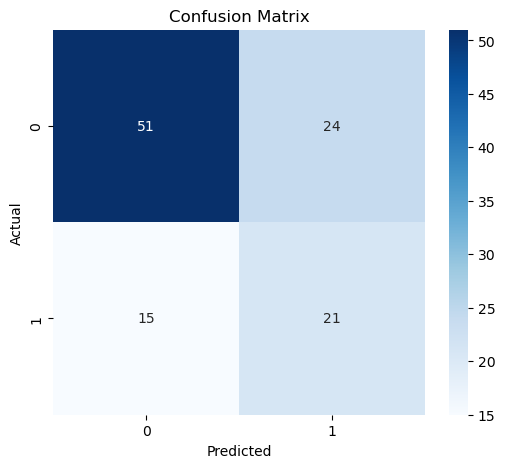

In [45]:
# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [46]:
# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_test_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.68      0.72        75
           1       0.47      0.58      0.52        36

    accuracy                           0.65       111
   macro avg       0.62      0.63      0.62       111
weighted avg       0.67      0.65      0.66       111



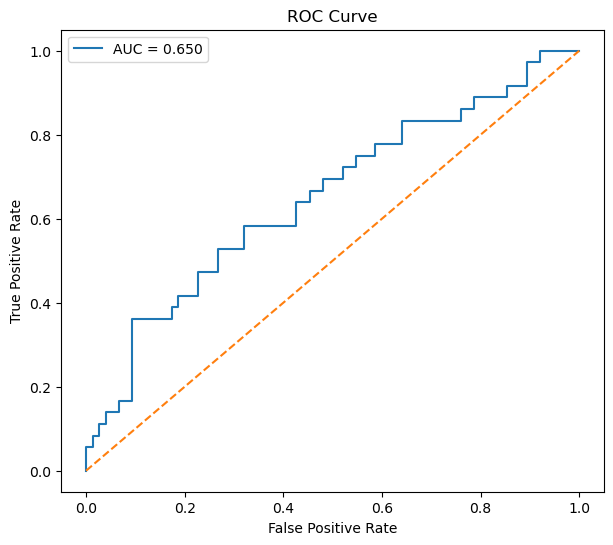

In [47]:
# ============================================================
# 20. ROC CURVE
# ============================================================

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


In [49]:
# ============================================================
# 21. BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

n_iterations = 1000

metrics_bootstrap = {

    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "mcc": [],
    "roc_auc": [],
    "pr_auc": [],
    "brier": []
}
for _ in range(n_iterations):

    X_res, y_res = resample(
        X_test,
        y_test,
        replace=True
    )

    y_prob = best_model.predict_proba(X_res)[:, 1]

    y_pred = (y_prob >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_res,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    metrics_bootstrap["accuracy"].append(
        accuracy_score(y_res, y_pred)
    )
    metrics_bootstrap["precision"].append(
        precision_score(y_res, y_pred)
    )

    metrics_bootstrap["recall"].append(
        recall_score(y_res, y_pred)
    )

    metrics_bootstrap["specificity"].append(
        specificity
    )

    metrics_bootstrap["f1"].append(
        f1_score(y_res, y_pred)
    )

    metrics_bootstrap["mcc"].append(
        matthews_corrcoef(y_res, y_pred)
    )

    metrics_bootstrap["roc_auc"].append(
        roc_auc_score(y_res, y_prob)
    )

    metrics_bootstrap["pr_auc"].append(
        average_precision_score(y_res, y_prob)
    )

    metrics_bootstrap["brier"].append(
        brier_score_loss(y_res, y_prob)
    )


In [50]:
# ============================================================
# 22. CONFIDENCE INTERVAL FUNCTION
# ============================================================

def compute_ci(values):

    lower = np.percentile(values, 2.5)

    upper = np.percentile(values, 97.5)

    mean = np.mean(values)

    return mean, lower, upper


print("\n========== 95% CONFIDENCE INTERVALS ==========")

for metric, values in metrics_bootstrap.items():

    mean, lower, upper = compute_ci(values)

    print(
        f"{metric.upper()}: "
        f"{mean:.3f} "
        f"(95% CI: {lower:.3f} - {upper:.3f})"
    )


========== 95% CONFIDENCE INTERVALS ==========
ACCURACY: 0.648 (95% CI: 0.559 - 0.739)
PRECISION: 0.466 (95% CI: 0.318 - 0.612)
RECALL: 0.582 (95% CI: 0.421 - 0.735)
SPECIFICITY: 0.680 (95% CI: 0.571 - 0.773)
F1: 0.515 (95% CI: 0.375 - 0.646)
MCC: 0.249 (95% CI: 0.066 - 0.434)
ROC_AUC: 0.648 (95% CI: 0.537 - 0.756)
PR_AUC: 0.517 (95% CI: 0.364 - 0.667)
BRIER: 0.225 (95% CI: 0.190 - 0.262)


In [51]:
# ============================================================
# 23. SHAP INTERPRETABILITY
# ============================================================

print("\nComputing SHAP Values...")

model = best_model.named_steps['classifier']

preprocessor = best_model.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP Computation Complete")


Computing SHAP Values...
SHAP Computation Complete


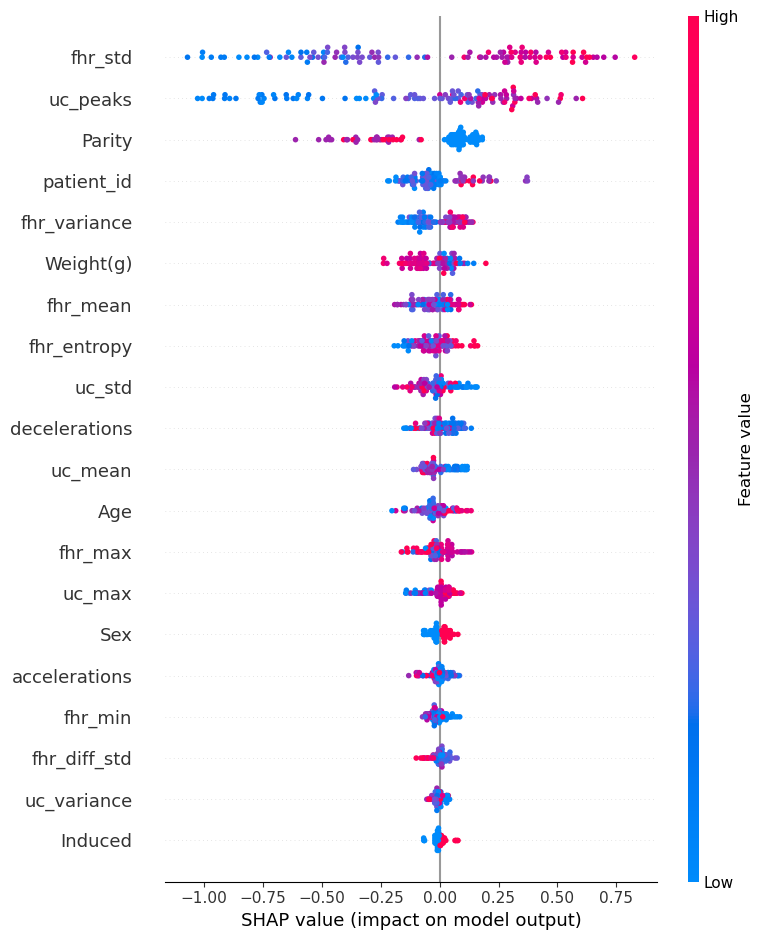

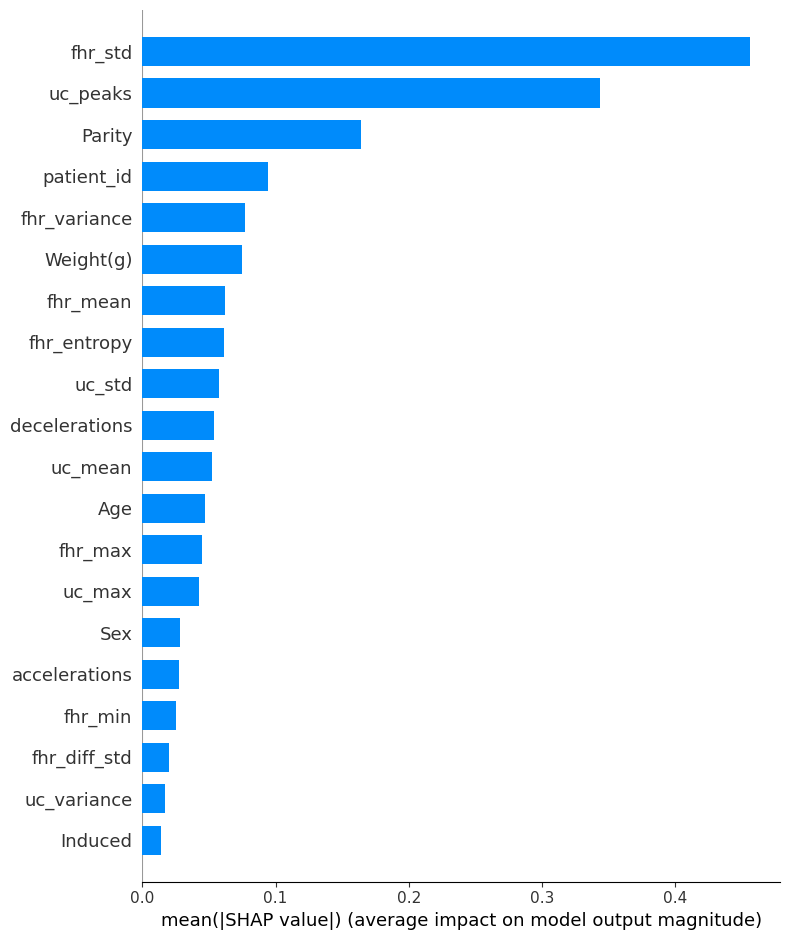

In [52]:
# ============================================================
# 24. SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)


# ============================================================
# 25. SHAP BAR PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

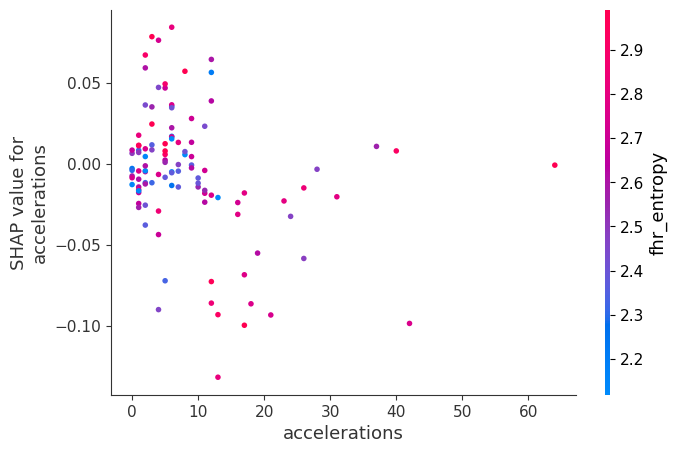

In [53]:
# ============================================================
# 26. OPTIONAL DEPENDENCE PLOTS
# ============================================================

# Replace feature names with your actual CTG features

TOP_FEATURES = [
    "baseline_fhr",
    "variability",
    "accelerations"
]

for feature in TOP_FEATURES:

    if feature in X_test.columns:

        shap.dependence_plot(
            feature,
            shap_values,
            X_test
        )


In [55]:
# ============================================================
# 27. SAVE MODEL
# ============================================================

import joblib

joblib.dump(best_model, r"C:\Users\vivek\Desktop\KI_Project\Project 3\best_xgboost_ctg_model.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully
